In [66]:
# 1. MOUNT DRIVE
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
# 2. IMPORTS
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import Input
from sklearn.metrics import classification_report, confusion_matrix
import os

In [56]:
# 3. PATHS
base_dir   = '/content/drive/MyDrive/Data'
train_path = base_dir + '/train'
valid_path = base_dir + '/valid'
test_path  = base_dir + '/test'

In [57]:
import os
for split in ['train', 'valid', 'test']:
    path = f'/content/drive/MyDrive/Data/{split}'
    for cls in os.listdir(path):
        count = len(os.listdir(os.path.join(path, cls)))
        print(f"{split}/{cls}: {count} images")

train/normal: 148 images
train/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 images
train/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 images
train/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 images
valid/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 21 images
valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 15 images
valid/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 23 images
valid/normal: 13 images
test/large.cell.carcinoma: 51 images
test/squamous.cell.carcinoma: 90 images
test/normal: 54 images
test/adenocarcinoma: 120 images


In [58]:
# 4. HYPERPARAMETERS
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 30
NUM_CLASSES = 4

In [59]:
# 5. DATA GENERATORS
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
valid_gen = val_test_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.samples)
print("Valid samples:", valid_gen.samples)
print("Test samples:", test_gen.samples)


Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Classes: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
Train samples: 613
Valid samples: 72
Test samples: 315


In [67]:
# 6. MODEL (MiniConvNet)
model = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(16, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,522,212 (24.88 MB)

 Trainable params: 6,521,732 (24.88 MB)

 Non-trainable params: 480 (1.88 KB)

In [61]:
# 7. COMPILE
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
# 8. CHECKPOINT
checkpoint = ModelCheckpoint(
    'miniconvnet_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,           # paper uses patience=10
    restore_best_weights=True,
    verbose=1
)


In [63]:
# 9. CLASS WEIGHTS (handles imbalance)
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.7858974358974359), 1: np.float64(1.3326086956521739), 2: np.float64(1.035472972972973), 3: np.float64(0.9887096774193549)}


In [64]:
# 10. TRAIN
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=valid_gen,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3986 - loss: 5.0725
Epoch 1: val_accuracy improved from None to 0.30556, saving model to miniconvnet_best.keras

Epoch 1: finished saving model to miniconvnet_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 150s 4s/step - accuracy: 0.4535 - loss: 4.1108 - val_accuracy: 0.3056 - val_loss: 3.3976
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5070 - loss: 1.6420
Epoch 2: val_accuracy did not improve from 0.30556
39/39 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.5024 - loss: 1.4888 - val_accuracy: 0.2083 - val_loss: 7.9426
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5337 - loss: 1.0312
Epoch 3: val_accuracy did not improve from 0.30556
39/39 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.5351 - loss: 1.0479 - val_accuracy: 0.2083 - val_loss: 9.4055
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5298 - loss: 1.0721
Epoch 4: val_accuracy did not improve from 0.30556
39/39 ━━━━━━━━━━━

In [65]:
# 11. LOAD BEST MODEL & EVALUATE ON TEST
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4413 - loss: 1.4055

Test Accuracy: 0.4413
Test Loss:     1.4055


In [29]:
# 11. CLASSIFICATION REPORT
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/step

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma       0.38      0.12      0.19       120
   large.cell.carcinoma       0.30      0.88      0.45        51
                 normal       0.91      0.98      0.95        54
squamous.cell.carcinoma       0.41      0.31      0.35        90

               accuracy                           0.45       315
              macro avg       0.50      0.57      0.48       315
           weighted avg       0.47      0.45      0.41       315



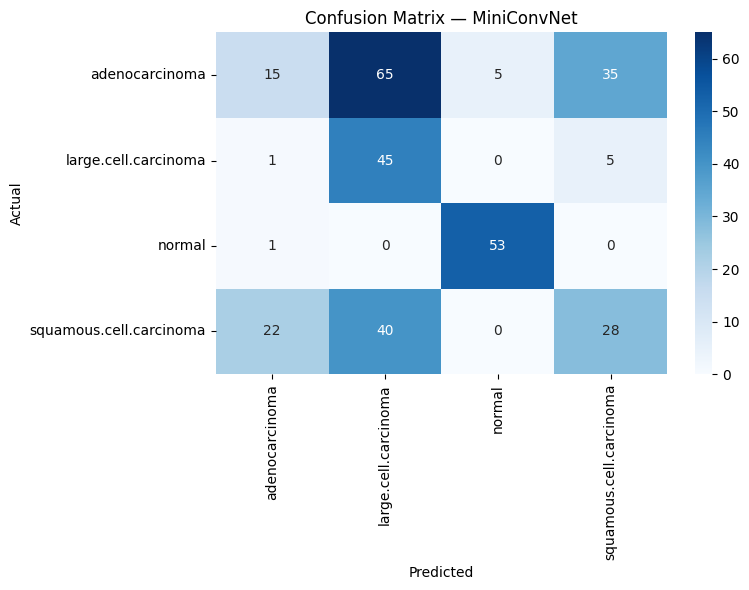

In [30]:
# 13. CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — MiniConvNet')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

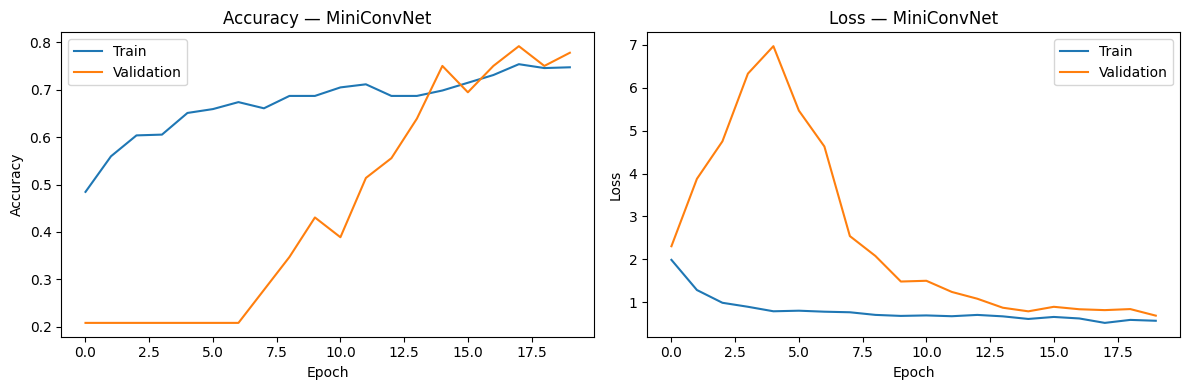

In [31]:
# 14. ACCURACY & LOSS PLOTS
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy — MiniConvNet')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss — MiniConvNet')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

In [ ]:
# 15. SAVE
model.save('miniconvnet_final.keras')
print("Model saved.")